In [ ]:
import pandas as pd

#Import data 
data = pd.read_csv("road_accident_dataset.csv")
data.info()

In [189]:
# List of columns to keep
columns_to_keep = [
    "Speed Limit",
    "Driver Alcohol Level",
    "Traffic Volume",
    "Population Density",
    "Visibility Level"
]

# Select only the desired columns
data_cleaned = data[columns_to_keep].copy()
data_cleaned.info()
data_cleaned.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132000 entries, 0 to 131999
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Speed Limit           132000 non-null  int64  
 1   Driver Alcohol Level  132000 non-null  float64
 2   Traffic Volume        132000 non-null  float64
 3   Population Density    132000 non-null  float64
 4   Visibility Level      132000 non-null  float64
dtypes: float64(4), int64(1)
memory usage: 5.0 MB


,Speed Limit,Driver Alcohol Level,Traffic Volume,Population Density,Visibility Level
0,37,0.05,7412.75,3866.27,220.41
1,96,0.23,4458.63,2333.92,168.31
2,62,0.14,9856.92,4408.89,341.29
3,78,0.12,4958.65,2810.82,489.38
4,98,0.16,3843.19,3883.65,348.34


# Feature Scaling

In [190]:
from sklearn.preprocessing import StandardScaler

# Select only numeric columns
numeric_cols = data_cleaned.select_dtypes(include=['int64', 'float64']).columns

# Standardize numerical features
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data_cleaned[numeric_cols])

#Convert back to DataFrame for easier handling
scaled_data_df = pd.DataFrame(scaled_data, columns=numeric_cols)
scaled_data_df.info()
scaled_data_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132000 entries, 0 to 131999
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Speed Limit           132000 non-null  float64
 1   Driver Alcohol Level  132000 non-null  float64
 2   Traffic Volume        132000 non-null  float64
 3   Population Density    132000 non-null  float64
 4   Visibility Level      132000 non-null  float64
dtypes: float64(5)
memory usage: 5.0 MB


,Speed Limit,Driver Alcohol Level,Traffic Volume,Population Density,Visibility Level
0,-1.44,-1.02,0.83,0.94,-0.42
1,0.83,1.52,-0.20,-0.12,-0.82
2,-0.48,0.24,1.68,1.32,0.51
3,0.13,-0.06,-0.03,0.21,1.65
4,0.90,0.42,-0.42,0.96,0.56


# PCA

In [191]:
from sklearn.decomposition import PCA

# Perform PCA 
pca = PCA(n_components=2) 
pca_data = pca.fit_transform(scaled_data_df)

# Convert PCA output to DataFrame
pca_df = pd.DataFrame(pca_data)
print("Number of PCA components:", pca.n_components_)


Number of PCA components: 2


[0.50063509 0.49936491]
[0.50063509 1.        ]


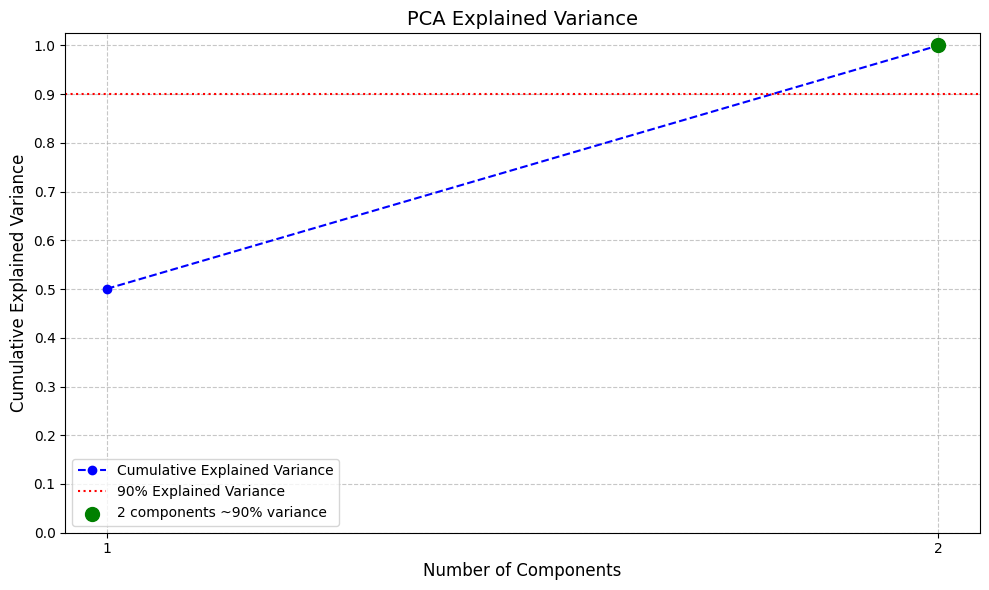

In [192]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(pca_df)
print(pca.explained_variance_ratio_)  # variance explained by each PC
print(pca.explained_variance_ratio_.cumsum())  # cumulative explained variance

# Cumulative explained variance
cum_var = pca.explained_variance_ratio_.cumsum()
num_components = len(cum_var)

plt.figure(figsize=(10,6))

# Plot cumulative variance
plt.plot(range(1, num_components + 1), cum_var, marker='o', linestyle='--', color='blue', label='Cumulative Explained Variance')

# Optional: plot a horizontal line at 90% variance
plt.axhline(y=0.9, color='red', linestyle=':', label='90% Explained Variance')

# Optional: highlight the number of components reaching 90%
components_90 = np.argmax(cum_var >= 0.9) + 1
plt.scatter(components_90, cum_var[components_90-1], color='green', s=100, zorder=5, label=f'{components_90} components ~90% variance')

# Labels and title
plt.xlabel("Number of Components", fontsize=12)
plt.ylabel("Cumulative Explained Variance", fontsize=12)
plt.title("PCA Explained Variance", fontsize=14)
plt.xticks(range(1, num_components + 1))
plt.yticks(np.linspace(0,1,11))
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()


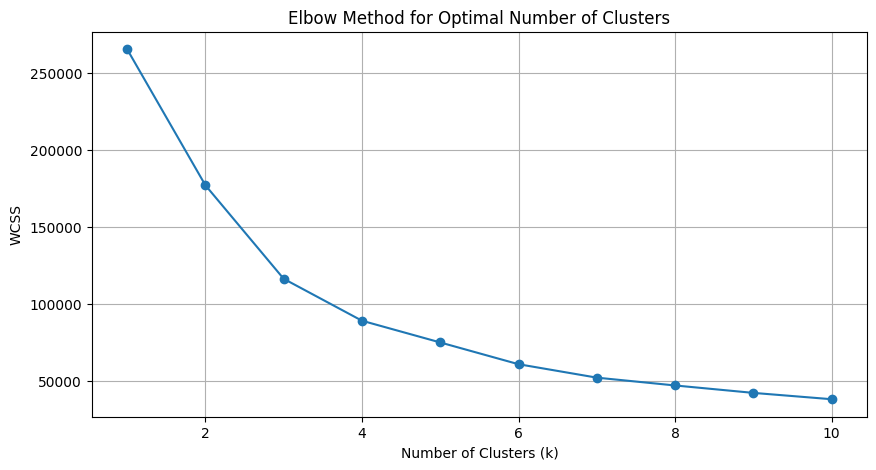

Optimal number of clusters (elbow point): 4


In [193]:
from sklearn.cluster import KMeans

wcss = []
K = range(1, 11) 

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(pca_df)
    wcss.append(kmeans.inertia_)  # inertia_ = WCSS

# Plot WCSS
plt.figure(figsize=(10,5))
plt.plot(K, wcss, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")
plt.title("Elbow Method for Optimal Number of Clusters")
plt.grid(True)
plt.show()

#Elbow detection using Kneedle
from kneed import KneeLocator
kl = KneeLocator(K, wcss, curve="convex", direction="decreasing")
optimal_k = kl.elbow
print("Optimal number of clusters (elbow point):", optimal_k)


Cluster
2    33373
0    33028
1    32873
3    32726
Name: count, dtype: int64


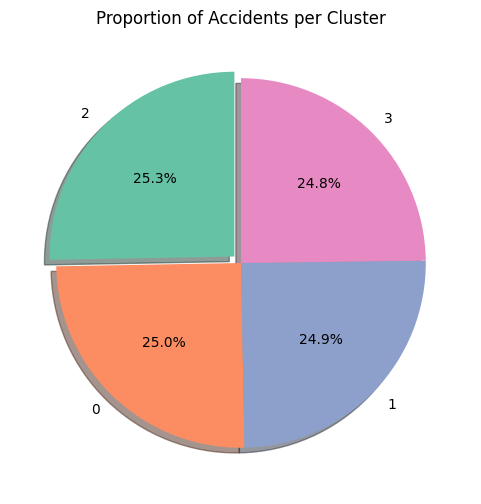

In [201]:
from sklearn.cluster import KMeans

# Initialize KMeans with optimal k
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
cluster_labels = kmeans.fit_predict(pca_df)

# Add cluster labels to original cleaned dataset
data_cleaned['Cluster'] = cluster_labels

# Check number of points per cluster
print(data_cleaned['Cluster'].value_counts())

# Calculate cluster counts
cluster_counts = data_cleaned['Cluster'].value_counts()

# Plot pie chart
plt.figure(figsize=(6,6))
plt.pie(cluster_counts.values,
        labels=cluster_counts.index,
        autopct='%1.1f%%',
        colors=sns.color_palette("Set2"),
        startangle=90,
        explode=[0.05 if i==cluster_counts.idxmax() else 0 for i in cluster_counts.index],
        shadow=True)
plt.title("Proportion of Accidents per Cluster")
plt.show()



In [202]:
# Take sample from PCA data
pca_df_sample = pca_df.sample(n=10000, random_state=42)

# Get the corresponding cluster labels
sample_labels = cluster_labels[pca_df_sample.index]

from sklearn.metrics import silhouette_score

sil_score = silhouette_score(pca_df_sample, sample_labels)

print("Silhouette Score:", sil_score)

Silhouette Score: 0.31745618987771823


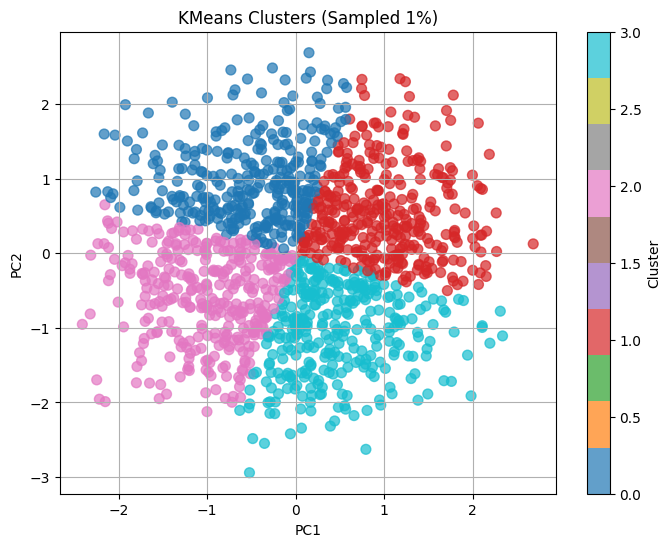

In [196]:
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------
# 1. Take a random sample of the data for plotting
# -------------------------------
sample_size = int(0.01 * pca_df.shape[0])  # 1% of data
sample_idx = np.random.choice(pca_df.shape[0], size=sample_size, replace=False)

#Limit to max 1000 points
#max_points = 1000
#n_points = min(max_points, pca_df.shape[0])
#sample_idx = np.random.choice(pca_df.shape[0], size=n_points, replace=False)

sample_data = pca_df.iloc[sample_idx]
sample_labels = np.array(cluster_labels)[sample_idx]

# -------------------------------
# 2. Scatter plot
# -------------------------------
plt.figure(figsize=(8,6))
plt.scatter(
    sample_data.iloc[:, 0], sample_data.iloc[:, 1],  # Use first two components/features
    c=sample_labels, 
    cmap='tab10', 
    s=50,        # marker size
    alpha=0.7,   # transparency
    #edgecolor='k'  # black edge for better visibility
)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('KMeans Clusters (Sampled 1%)')
plt.colorbar(label='Cluster')
plt.grid(True)
plt.show()


In [206]:
cluster_profiles = data_cleaned.groupby("Cluster")[columns_to_keep].mean()
print(cluster_profiles)


         Speed Limit  Driver Alcohol Level  Traffic Volume  Population Density  Visibility Level
Cluster                                                                                         
0              57.75                  0.11         7003.90             1557.63            276.01
1              69.90                  0.19         6496.19             3258.37            307.05
2              79.25                  0.06         3588.47             1777.26            243.81
3              91.36                  0.14         3083.26             3452.44            273.75


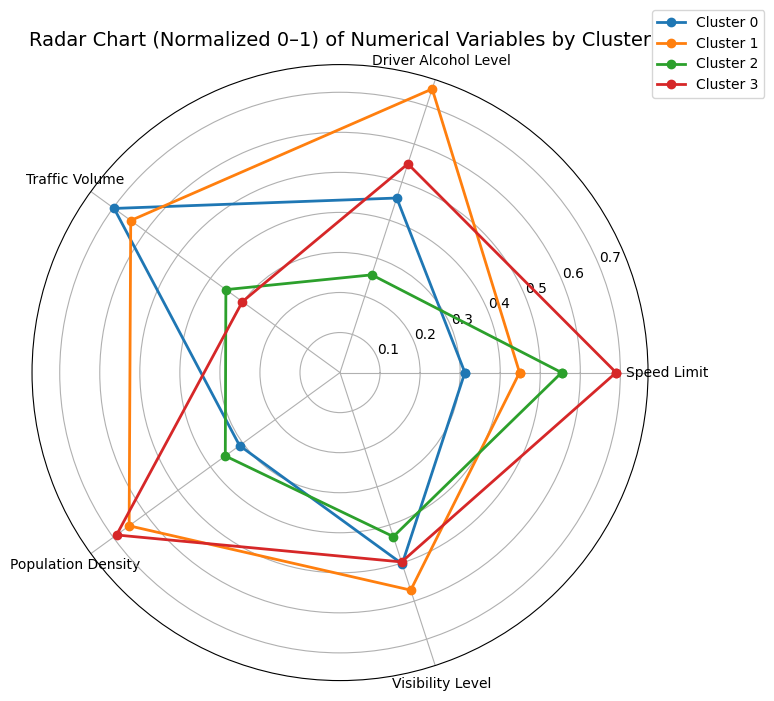

In [150]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Scale 0–1
scaler = MinMaxScaler()
scaled = scaler.fit_transform(data_cleaned[columns_to_keep])

scaled_df = pd.DataFrame(scaled, columns=columns_to_keep)
scaled_df['Cluster'] = data_cleaned['Cluster']

# Mean for radar
cluster_means = scaled_df.groupby('Cluster')[columns_to_keep].mean()

# Radar setup
N = len(columns_to_keep)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(10, 8))

for cluster in cluster_means.index:
    values = cluster_means.loc[cluster].tolist()
    values += values[:1]
    plt.polar(angles, values, marker='o', linewidth=2, label=f"Cluster {cluster}")

plt.xticks(angles[:-1], columns_to_keep)
plt.title("Radar Chart (Normalized 0–1) of Numerical Variables by Cluster", fontsize=14)
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))

plt.show()


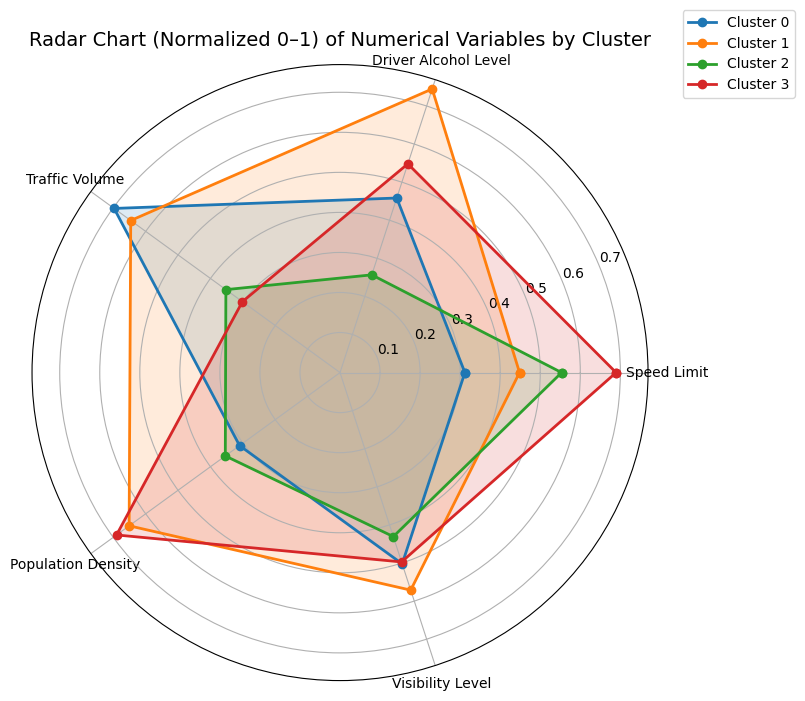

In [151]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler


# Scale 0–1
scaler = MinMaxScaler()
scaled = scaler.fit_transform(data_cleaned[columns_to_keep])

scaled_df = pd.DataFrame(scaled, columns=columns_to_keep)
scaled_df['Cluster'] = data_cleaned['Cluster']

# Mean for radar
cluster_means = scaled_df.groupby('Cluster')[columns_to_keep].mean()

# Radar setup
N = len(columns_to_keep)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(10, 8))

for cluster in cluster_means.index:
    values = cluster_means.loc[cluster].tolist()
    values += values[:1]
    
    # Plot line
    plt.polar(angles, values, marker='o', linewidth=2, label=f"Cluster {cluster}")
    
    # Fill shade
    plt.fill(angles, values, alpha=0.15)   # light shading

plt.xticks(angles[:-1], columns_to_keep)
plt.title("Radar Chart (Normalized 0–1) of Numerical Variables by Cluster", fontsize=14)
plt.legend(loc='upper right', bbox_to_anchor=(1.25, 1.1))

plt.show()


In [114]:
cluster_means.min(), cluster_means.max()



(Visibility Level        0.430679
 Speed Limit             0.311797
 Driver Alcohol Level    0.256636
 Traffic Volume          0.301335
 Population Density      0.310147
 dtype: float64,
 Visibility Level        0.571230
 Speed Limit             0.689386
 Driver Alcohol Level    0.744751
 Traffic Volume          0.697362
 Population Density      0.689868
 dtype: float64)

C:\Users\ACER NITRO\AppData\Local\Temp\ipykernel_24272\2710335655.py:50: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1.05))


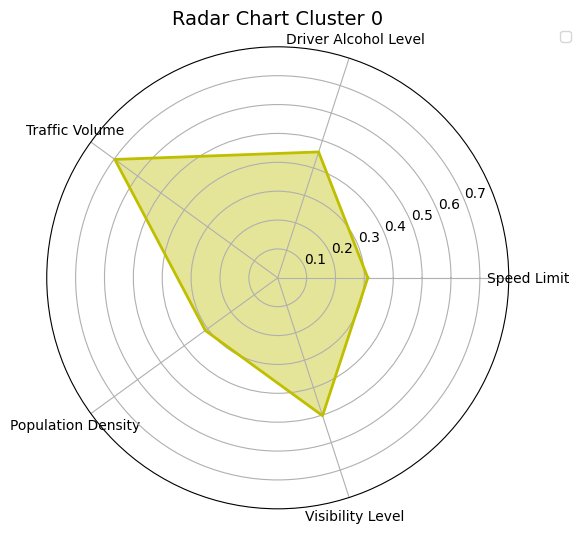

C:\Users\ACER NITRO\AppData\Local\Temp\ipykernel_24272\2710335655.py:50: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1.05))


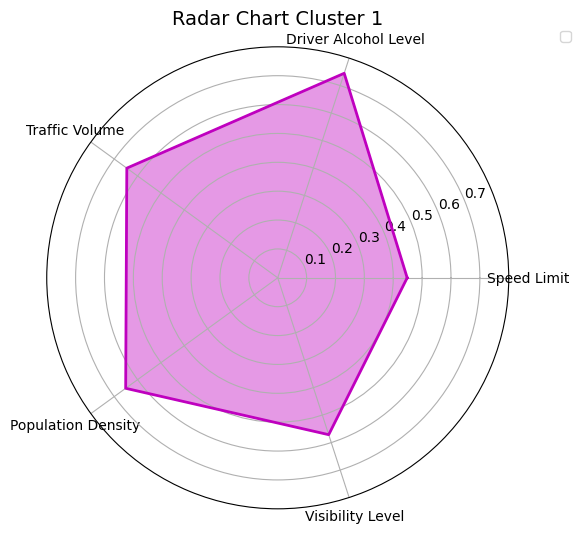

C:\Users\ACER NITRO\AppData\Local\Temp\ipykernel_24272\2710335655.py:50: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1.05))


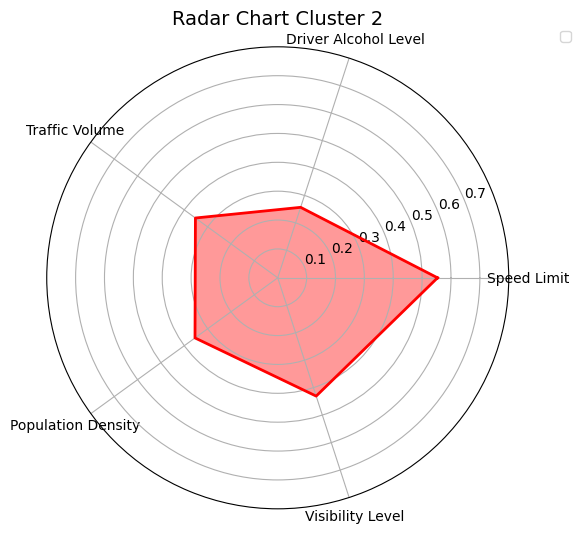

C:\Users\ACER NITRO\AppData\Local\Temp\ipykernel_24272\2710335655.py:50: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1.05))


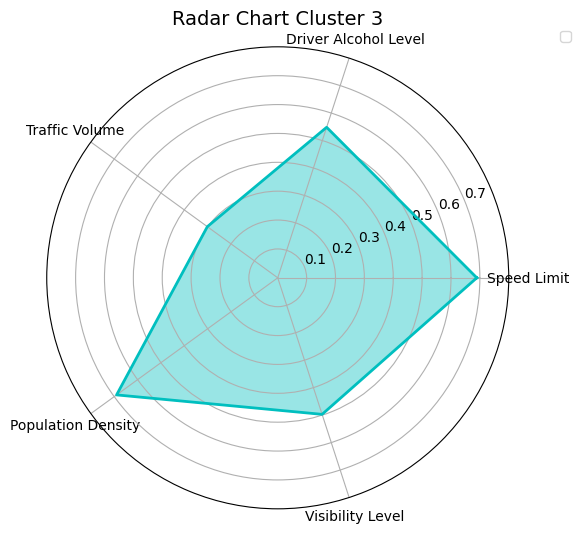

In [211]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Scale 0–1
scaler = MinMaxScaler()
scaled = scaler.fit_transform(data_cleaned[columns_to_keep])

scaled_df = pd.DataFrame(scaled, columns=columns_to_keep)
scaled_df['Cluster'] = data_cleaned['Cluster']

# Mean for radar
cluster_means = scaled_df.groupby('Cluster')[columns_to_keep].mean()

# Radar setup
N = len(columns_to_keep)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close loop

# Radial ticks
radial_ticks = [0.1,0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
colors = ['y', 'm', 'r', 'c']  


# Create 1 radar chart per cluster
for cluster in cluster_means.index:
    values = cluster_means.loc[cluster].tolist()
    values += values[:1]

    plt.figure(figsize=(8, 6))
    ax = plt.subplot(111, polar=True)

    # Set radial scale 0.2 to 0.8
    ax.set_ylim(0.0, 0.8)
    ax.set_yticks(radial_ticks)
    ax.set_yticklabels([str(t) for t in radial_ticks])

    # Plot + fill
    color = colors[cluster % len(colors)]  # cycle colors if >6 clusters
    ax.plot(angles, values, linewidth=2, color=color)
    ax.fill(angles, values, color=color, alpha=0.4)  # stronger fill
    #ax.plot(angles, values, linewidth=2,)
    #ax.fill(angles, values, alpha=0.15)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(columns_to_keep)

    plt.title(f"Radar Chart Cluster {cluster}", fontsize=14)
    plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1.05))

    plt.show()


In [99]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# -------------------------------
# Clustering without PCA
# -------------------------------

# Initialize KMeans with optimal k
kmeans = KMeans(n_clusters=4, random_state=42)
cluster_labels = kmeans.fit_predict(scaled_data_df)

# Add cluster labels to original cleaned dataset
data_cleaned['Cluster'] = cluster_labels

# Check number of points per cluster
print(data_cleaned['Cluster'].value_counts())

# Take sample from scaled data for evaluation
scaled_sample = scaled_data_df.sample(n=10000, random_state=42)

# Get the corresponding cluster labels
sample_labels = cluster_labels[scaled_sample.index]

# -------------------------------
# Cluster evaluation
# -------------------------------
sil_score = silhouette_score(scaled_sample, sample_labels)


print("Silhouette Score:", sil_score)


Cluster
0    33105
2    33021
3    32976
1    32898
Name: count, dtype: int64
Silhouette Score: 0.14119783365898744
